# Overview:
This is a simple demonstration of how low-level spam filters work. We will be using Multinoulli Naive Bayes' algorithm as our method to design such a filter, and will be using numerical values to simulate dictionary words. The numbers so used will not be accurate to the real dictionary, but the algorithm as a whole is similar to how the filter works.

## Theory:
Suppose a dataset $\mathcal{D} = \{(x^{(i)}, \, y^{(i)})\}_{i = 1}^{m}$, with $y^{(i)} \in \{0, \, 1\}$ and $x^{(i)} \in D^{n^{(i)}}$, where D denotes the dictionary containing n words (labelled 1 to n) and $n^{(i)}$ is the no. of features in given sample.
1. Here, each $i^{th}$ input $(x^{(i)}, \, y^{(i)})$ represents a sample mail, with $y^{(i)} = 0$ denoting a non-spam mail and $y^{(i)} = 1$ being a spam mail. The input label $x^{(i)}$ denotes the text of the mail, with each mail having a variable $n^{(i)}$ no. of words.
2. Now, an important assumption we take: $$ x^{(i)}_j = k \, | \, Y = y^{(i)} \sim Multinoulli(\phi_{x^{(i)}_j = 1|Y = y^{(i)}}, \, \phi_{x^{(i)}_j = 2|Y = y^{(i)}}, \,..\, \phi_{x^{(i)}_j = n|Y = y^{(i)}})$$ which means $$\Rightarrow P(x^{(i)}_j = k | Y = y^{(i)}) = \phi_{x^{(i)}_j = k|Y = y^{(i)}} $$
3. We also assume: $$ Y \sim Bernoulli(\phi_y) $$ which means $$\Rightarrow P(Y = y^{(i)}) = \phi_y^{y^{(i)}} (1 - \phi_y)^{1 - y^{(i)}}$$
4. Now, we find the Joint-probability of $P(X = x^{(i)} \cap Y = y^{(i)})$ using $P(x^{(i)}_j = k | Y = y^{(i)})$, along with a few assumptions: $$P(X = x^{(i)} \cap Y = y^{(i)}) = P(\cap_{j = 1}^{n^{(i)}} (x^{(i)}_j = k_j^{(i)}) \cap Y = y^{(i)}) $$ Here, assuming all words are independent of each other: $$\Rightarrow P(X = x^{(i)} \cap Y = y^{(i)}) = P(Y = y^{(i)}) \prod_{j = 1}^{n^{(i)}} P(x^{(i)}_j = k_j^{(i)})$$ This assumption is flawed in the practical sense, since rules of grammar allow only a certain pair of words to be grouped together, whereas in this case we assume any word can be grouped with any word. Our model assumes a sentence like "Hello Cat Blue dog" to be a grammatically sound and meaningful sentence, when in actuality it is clearly not. For the sake of simplicity though, we assume this to be the case.
5. Now, constructing our MLE through the Joint-likelihood function, we get: $$ J(\phi_{1|Y = 1}, \, \phi_{2|Y = 1}, .. \phi_{n|Y = 1}, \, \phi_{1|Y = 0}, \, \phi_{2|Y = 0}, .. \phi_{n|Y = 0}) = \prod_{i = 1}^{m}P(X = x^{(i)} \cap Y = y^{(i)})$$ which becomes $$\prod_{i = 1}^{m} P(Y = y^{(i)}) \prod_{j = 1}^{n^{(i)}} P(x^{(i)}_j = k^{(i)}_j | Y = y^{(i)}) $$
6. Now, constructing the log-likelihood of this and differentiating with respect to the parameter required to be solved, we get: $$ \phi_{k|Y = y} = \frac{\sum_{i = 1}^{m} \mathcal{I}\{y^{(i)} = y\} \sum_{j = 1}^{n^{(i)}} \mathcal{I}\{x_j^{(i)} = k\}}{\sum_{i = 1}^{m} \mathcal{I}\{y^{(i)} = y\}n^{(i)}} $$ and $$\phi_y = \frac{\sum_{i = 1}^{m} \mathcal{I}\{y^{(i)} = 1\}}{m} $$ where $\mathcal{I}\{C = c\}$ is the indicator function. If the conditions inside it is satisfied, then the function yields a numerical 1, numerical 0 otherwise.

## Objective of the model:
Generally, spams contain the same type of words recurring throughout multiple mails. This model will try to generalize which words in particular are more likely to be found in the spam-mails using the dataset $\mathcal{D}$ and then for some given query mails, it will predict if they are spam or not on basis of the generalization it has learnt from the dataset.

In [75]:
#Importing all the main libraries.
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

In [76]:
#Now we prepare our dataset and query-space for simulation of the spam filter.

#Generating a random seed. 99 is a randomly chosen number.
np.random.seed(99)
#We will simulate a dataset of 300 E-mails, each with having words between 20 to 100 distributed uniformly per mail as our design choice.
#We will generate 500 mails, of which the first 400 will serve as our main dataset, and the rest 100 will be our query-space with the real labels available.
#This will allow us to verify our model on the query-labels, and whether the prediction is correct or not.
n_words = np.random.uniform(low = 20, high = 101, size = (500, 1))
#We will be using a hypothetical dictionary of 1000 words for simulating the filter, each word labelled from 1 to 1000.
#The words will be distributed uniformly. This is an arbitrary design choice.
X_raw = []
#Store the samples in an array.
for _ in range(500):
    n_i = n_words[_, 0]
    sample_i = np.random.uniform(low = 1, high = 1001, size = int(n_i))
    X_raw.append(sample_i)
#Now, we simulate which mails are spam mails and which ones are not.
#For this, we put the following arbitrary condition: If any sample contains words between [300, 303], then that mail will be called spam.
#That's ultimately 4 particular words most likely to be found in a spam mail.
Y = np.array([int(np.any((300 <= sample) & (sample <= 303))) for sample in X_raw])
#Now, we randomly flip 10% of the 1 (yes-spam) labels to 0 (not-spam) labels as a simulation of noise in the dataset.
spam_indices = np.where(Y == 1)[0]
#We find the indices of all those mails which have label as 1.
#We calculate the number of flips (10% of all the spam mails).
flips = int(0.1 * len(spam_indices))
flips_indices = np.random.choice(spam_indices, flips, replace = False)
#Choose random indices for flipping the labels.
Y[flips_indices] = 0
#Now we split this data so as to form a 400 element dataset and a 100 element query space for verification of our model.
X_dataset = X_raw[:400]
X_queries = X_raw[400:]
Y_dataset = Y[:400]
Y_queries = Y[400:]
#Now we verify the shapes.
print(len(X_dataset))
print(len(X_queries))
print(len(Y_dataset))
print(len(Y_queries))

400
100
400
100


In [77]:
#Now, by the simple GDA + Naive Bayes' algorithm, we set the parameters of occurence of Y = y as the following:
phi_y = len(np.where(Y_dataset == 1)[0]) / len(Y_dataset)
#Now, we calculate the multinoulli parameters for each and every word according to the formula given above.
#First, we define the dictionary of size D and no. of samples.
D = 1000
n_samples = 400
#Our strategy involves making a matrix of shape n_samples x D such that for the ith sample mail, the matrix stores no. of words of each type in the column.
#Each column corresponds to a type of word, and the value in any index ij corresponds to how many of j-type words are there in the ith mail.
word_count = np.zeros((n_samples, D), dtype = int)
#Now, we store the counts of each type of word in the ith mail, in the above matrix.
for i, sample in enumerate(X_dataset):
    word_count_i = np.bincount(sample.astype(int) - 1, minlength = D)
    word_count[i] = word_count_i
#We then split the mails by their label-type.
mails_nospam = (Y_dataset == 0)
mails_spam = (Y_dataset == 1)
#We then take the counts of all words, given if y = 0 or if y = 1, and then store them in 2 separate arrays of length D.
words_nospam = word_count[mails_nospam].sum(axis = 0)  
words_spam = word_count[mails_spam].sum(axis = 0)  
#We find the total words in each array.
tot_nospam = words_nospam.sum()
tot_spam = words_spam.sum()
#Applying Laplace smoothing to ensure non-zero probabilities, we get the following multinoulli parameter array for y = 0 and y = 1 ,per word, respectively.
phi_y_0 = (words_nospam + 1) / (tot_nospam + D)
phi_y_1 = (words_spam + 1) / (tot_spam + D)

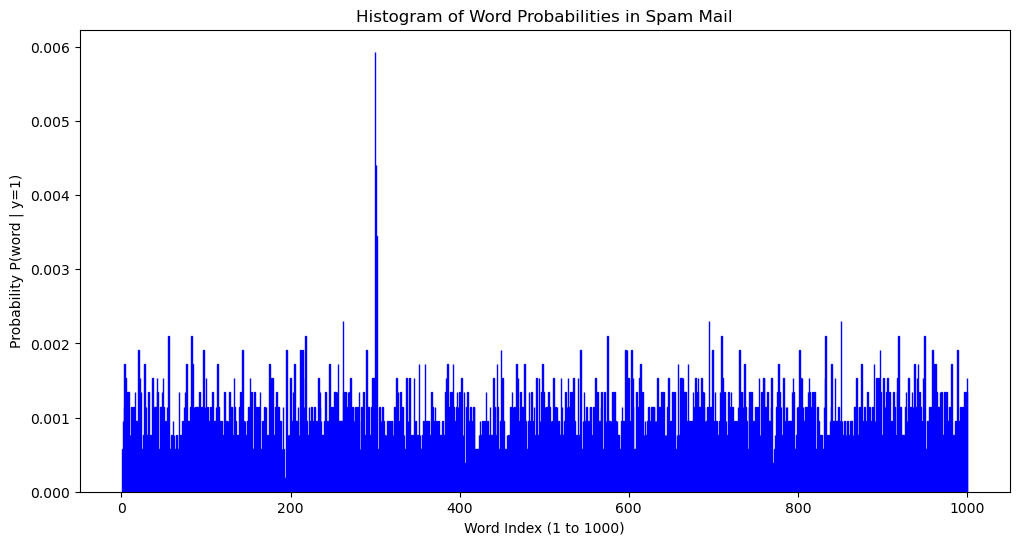

In [78]:
#Plotting a histogram between the probabilities of each word being in a spam mail wrt the word itself (the word index in the dictionary)
plt.figure(figsize = (12, 6))
plt.bar(range(1, len(phi_y_1) + 1), phi_y_1, color = 'black', edgecolor = 'blue')
plt.xlabel("Word Index (1 to 1000)")
plt.ylabel("Probability P(word | y=1)")
plt.title("Histogram of Word Probabilities in Spam Mail")
plt.show()

The graph shows a sharp spike in the probabilities for the words $[300,303]$, which was as intended in the model. Our simulation structured the words of those particular indices to be present in a given spam mail. Our model helped in generalizing that very well.

In [80]:
#Now, we fetch our sample queries, and run our Naive Bayes' model on those sample mails to determine if they are spam or not:
correct_preds = 0
#Fetch the correct no. of predictions of spam and non-spam.
for q, sample in enumerate(X_queries):
    #Producing an array of word-type per qth mail.
    word_count_q = np.bincount(sample.astype(int) - 1, minlength = D)
    #Calculating the proportional element of the posterior log-likelihood of P(Y = 1 | X = xi) and P(Y = 0 | X = xi).
    #We use the log-posterior probability instead of the main probability to prevent underflows in memory.
    #Mathematically, the comparison holds valid still, since logarithm is a monotonic increasing function.
    log_post_y0 = np.sum(word_count_q * np.log(phi_y_0)) + np.log(1 - phi_y)
    log_post_y1 = np.sum(word_count_q * np.log(phi_y_1)) + np.log(phi_y)
    #Formalising the prediction in a boolean form.
    y_q_pred = int(log_post_y1 > log_post_y0)
    correct_preds += int(y_q_pred == Y_queries[q])
    #Adding 1 to correct no. of predictions if correct.
print(correct_preds)
#This is the percentage of correct predidictions.

90
